# 第37篇｜相关性分析：皮尔逊 / 斯皮尔曼 / 点二列

> 这是「数据分析从入门到精通」系列的第 37 篇。假设检验掌握了，这篇来聊相关性分析。广告投入和销售额有关系吗？两个变量怎么量化它们之间的关联？皮尔逊、斯皮尔曼、点二列，不同数据类型对应不同方法，这篇一次讲清。

---

嗨，我是小荷～

"广告费越多，销售额越高吗？"
"用户年龄和客单价有关系吗？"
"好评率和复购率相关吗？"

这些问题都需要**相关性分析**来回答。

但"相关性"不是一个万能指标——数据类型不同，要用不同的相关系数。今天来学三种最常用的。

---

## 一、相关系数的含义

相关系数 r（或 ρ）的取值范围是 [-1, 1]：

| r 值 | 含义 |
|------|------|
| +1 | 完全正相关 |
| 0.7~1 | 强正相关 |
| 0.4~0.7 | 中等正相关 |
| 0.1~0.4 | 弱正相关 |
| ≈ 0 | 无线性相关 |
| 负值 | 负相关（方向相反） |
| -1 | 完全负相关 |

> ⚠️ **记住：相关 ≠ 因果**！冰淇淋销量和溺水事故高度相关——因为两者都跟夏天有关，并不是吃冰淇淋导致溺水。

---

## 二、皮尔逊相关系数（Pearson）

适用场景：**两个连续变量，线性关系，近似正态分布**。


In [1]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

plt.rcParams['font.sans-serif'] = ['WenQuanYi Micro Hei']   # 文泉驿微米黑
plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style='whitegrid')

np.random.seed(42)
n = 200

# 构造不同强度的相关性
ad_spend = np.random.uniform(10, 100, n)
sales_strong = ad_spend * 4.5 + np.random.normal(0, 20, n)    # 强相关
sales_weak   = ad_spend * 1.0 + np.random.normal(0, 80, n)    # 弱相关
sales_none   = np.random.normal(300, 80, n)                    # 无关

for name, y in [('强相关', sales_strong), ('弱相关', sales_weak), ('无关', sales_none)]:
    r, p = stats.pearsonr(ad_spend, y)
    print(f"{name}：r = {r:.3f}，p = {p:.4f}")


强相关：r = 0.987，p = 0.0000
弱相关：r = 0.354，p = 0.0000
无关：r = 0.017，p = 0.8085


单个变量的相关系数看完了，接下来算一算完整的相关矩阵：


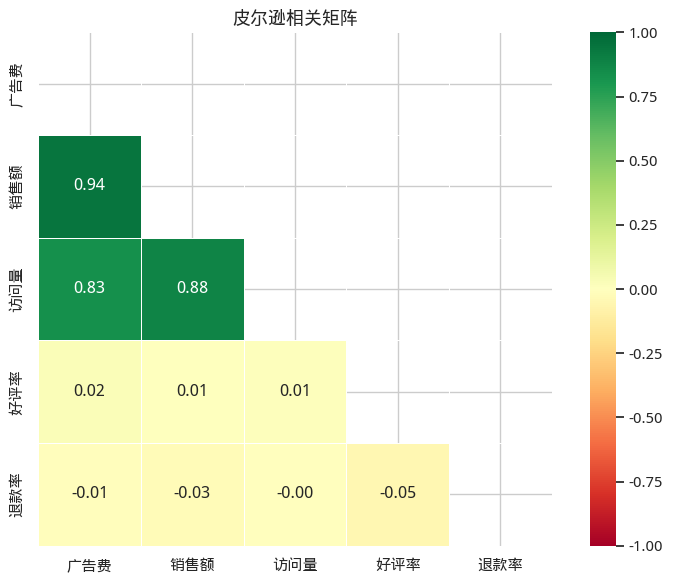

In [5]:
# 计算相关矩阵
df = pd.DataFrame({
    '广告费':  np.random.uniform(10, 100, 300),
    '销售额':  np.random.uniform(100, 1000, 300),
    '访问量':  np.random.uniform(500, 5000, 300),
    '好评率':  np.random.uniform(0.7, 1.0, 300),
    '退款率':  np.random.uniform(0, 0.15, 300)
})
df['销售额'] = df['广告费'] * 3.5 + np.random.normal(0, 30, 300)
df['访问量'] = df['销售额'] * 4 + np.random.normal(0, 200, 300)

corr = df.corr(method='pearson')

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
             vmin=-1, vmax=1, center=0, square=True, linewidths=0.5, ax=ax)
ax.set_title('皮尔逊相关矩阵', fontsize=13, fontweight='bold')

plt.rcParams['font.sans-serif'] = ['WenQuanYi Micro Hei']   # 文泉驿微米黑
plt.tight_layout()
plt.show()


---

## 三、斯皮尔曼相关系数（Spearman）

适用场景：
- 数据是**顺序数据**（如评分 1-5、满意度等级）
- 数据**严重偏态**（如收入、销售金额）
- 数据**有异常值**
- 两变量的关系是**单调**但**非线性**的

斯皮尔曼本质是对排名做皮尔逊相关。


In [6]:
# 场景：商品评分（1-5）和销量的相关性
np.random.seed(42)
n = 200
rating = np.random.choice([1, 2, 3, 4, 5], n, p=[0.05, 0.1, 0.2, 0.4, 0.25])
sales  = rating * 50 + np.random.normal(0, 40, n)

# 皮尔逊（对评分这种顺序数据不太合适）
r_p, p_p = stats.pearsonr(rating, sales)
# 斯皮尔曼（更合适）
r_s, p_s = stats.spearmanr(rating, sales)

print(f"皮尔逊 r = {r_p:.3f}，p = {p_p:.4f}")
print(f"斯皮尔曼 ρ = {r_s:.3f}，p = {p_s:.4f}")


皮尔逊 r = 0.823，p = 0.0000
斯皮尔曼 ρ = 0.827，p = 0.0000


---

## 四、点二列相关（Point-Biserial）

适用场景：一个**连续变量** + 一个**二元变量（0/1）**。


点二列相关系数：r = 0.724，p = 0.0000


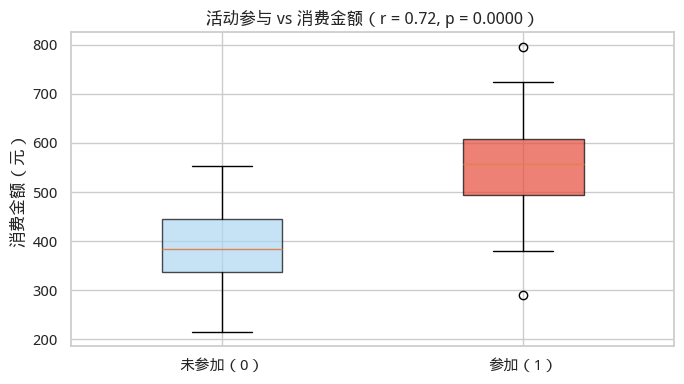

In [7]:
# 场景：是否参加活动（0/1）与消费金额的相关
np.random.seed(42)
n = 300
participated = np.random.choice([0, 1], n, p=[0.4, 0.6])
amount = participated * 150 + np.random.normal(400, 80, n)

# point-biserial 就是皮尔逊的特例，scipy 里用同一个函数
r_pb, p_pb = stats.pointbiserialr(participated, amount)
print(f"点二列相关系数：r = {r_pb:.3f}，p = {p_pb:.4f}")

# 可视化
fig, ax = plt.subplots(figsize=(7, 4))
groups = ['未参加（0）', '参加（1）']
for i, (label, group_val) in enumerate(zip(groups, [0, 1])):
    data_g = amount[participated == group_val]
    ax.boxplot(data_g, positions=[i], widths=0.4,
                patch_artist=True,
                boxprops=dict(facecolor=['#AED6F1', '#E74C3C'][i], alpha=0.7))

ax.set_xticks([0, 1])
ax.set_xticklabels(groups)
ax.set_title(f'活动参与 vs 消费金额（r = {r_pb:.2f}, p = {p_pb:.4f}）', fontweight='bold')
ax.set_ylabel('消费金额（元）')
plt.tight_layout()
plt.show()


---

## 五、三种相关系数对比

| 相关系数 | 适用场景 | 数据要求 |
|---------|---------|---------|
| 皮尔逊（r） | 两个连续变量 | 正态、无离群值、线性关系 |
| 斯皮尔曼（ρ） | 顺序数据或偏态连续数据 | 单调关系即可，对分布无要求 |
| 点二列（r_pb） | 连续 + 二元（0/1） | — |

**选择原则**：
1. 两个连续变量 → 先看散点图，线性关系用皮尔逊，否则用斯皮尔曼
2. 有顺序量表（1-5分）→ 斯皮尔曼
3. 一个连续 + 一个二值 → 点二列

---

## 六、🔧 综合实战：找出影响房价的关键因素

学了一堆理论，来个完整的实战练练手——把前面学的知识点串起来：


各变量与房价的相关系数（皮尔逊 + 斯皮尔曼）
变量                皮尔逊 r         p值       斯皮尔曼 ρ         p值
--------------------------------------------------------------------------------
面积              0.925***     0.0000      0.932***   0.0000
楼层             -0.003ns     0.9530      0.000ns   0.9930
建筑年份            0.005ns     0.9179      0.005ns   0.9183
距地铁距离          -0.112 *     0.0124     -0.100 *   0.0256
学区评分            0.207***     0.0000      0.185***   0.0000
停车位数量           0.104 *     0.0205      0.084ns   0.0616


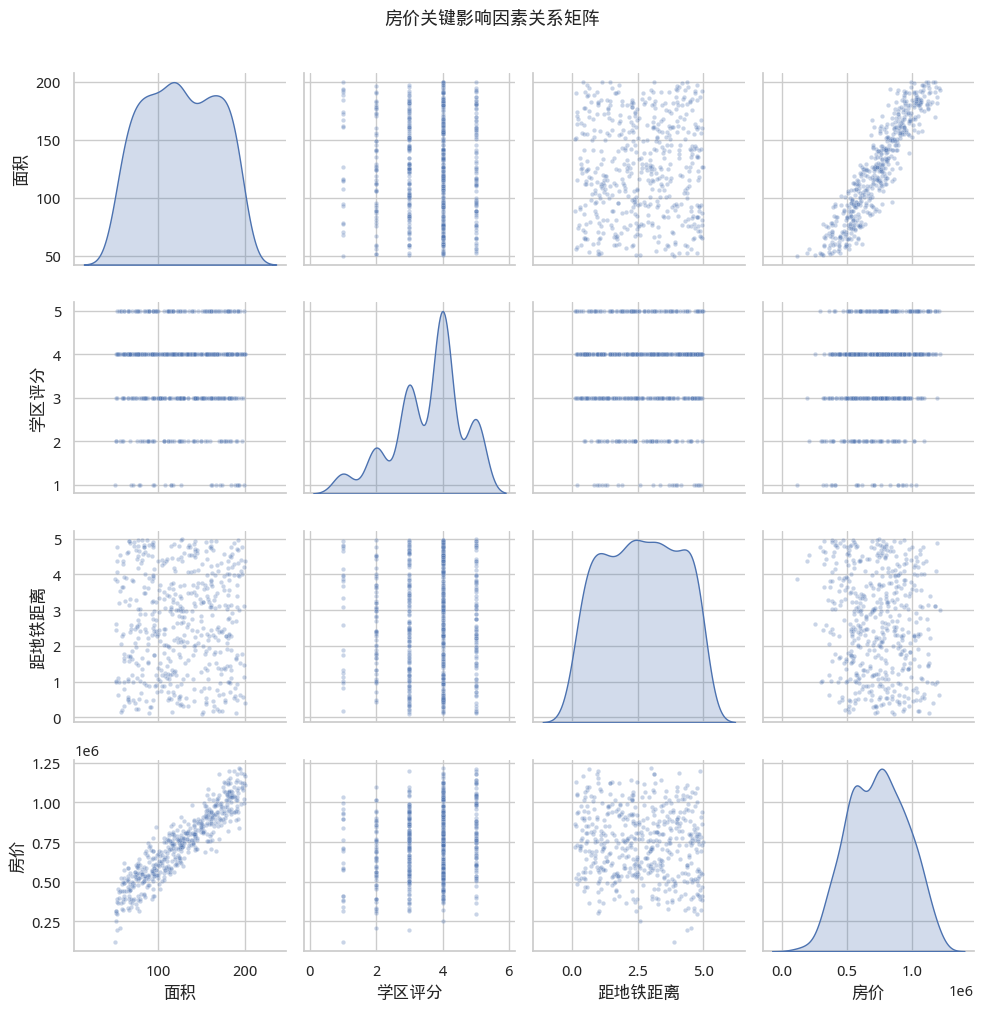

In [30]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.sans-serif'] = ['WenQuanYi Micro Hei']   # 文泉驿微米黑
plt.rcParams['axes.unicode_minus'] = False

np.random.seed(2024)
n = 500

df = pd.DataFrame({
    '面积':      np.random.uniform(50, 200, n),
    '楼层':      np.random.randint(1, 30, n),
    '建筑年份':  np.random.randint(1990, 2026, n),
    '距地铁距离': np.random.uniform(0.1, 5.0, n),
    '学区评分':  np.random.choice([1,2,3,4,5], n, p=[0.05, 0.1, 0.25, 0.4, 0.2]),
    '停车位数量': np.random.choice([0, 1, 2], n, p=[0.2, 0.5, 0.3])
})

# 构造价格（含非线性关系）
df['房价'] = (
    df['面积'] * 5000
    + (df['学区评分'] ** 1.5) * 20000
    - df['距地铁距离'] * 20000
    + df['停车位数量'] * 30000
    + (2026 - df['建筑年份']) * (-500)
    + np.random.normal(0, 50000, n)
)

print("各变量与房价的相关系数（皮尔逊 + 斯皮尔曼）")
print("="*80)
print(f"{'变量':<12} {'皮尔逊 r':>10} {'p值':>10} {'斯皮尔曼 ρ':>12} {'p值':>10}")
print("-"*80)

for col in ['面积', '楼层', '建筑年份', '距地铁距离', '学区评分', '停车位数量']:
    r_p, p_p = stats.pearsonr(df[col], df['房价'])
    r_s, p_s = stats.spearmanr(df[col], df['房价'])
    sig_p = '***' if p_p < 0.001 else '**' if p_p < 0.01 else '*' if p_p < 0.05 else 'ns'
    sig_s = '***' if p_s < 0.001 else '**' if p_s < 0.01 else '*' if p_s < 0.05 else 'ns'
    print(f"{col:<12} {r_p:>8.3f}{sig_p:>2} {p_p:>10.4f} {r_s:>10.3f}{sig_s:>2} {p_s:>8.4f}")

# 可视化：散点图矩阵（关键变量）
key_cols = ['面积', '学区评分', '距地铁距离', '房价']
sns.pairplot(df[key_cols], plot_kws={'alpha': 0.3, 's': 10}, diag_kind='kde')
plt.suptitle('房价关键影响因素关系矩阵', y=1.01, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


我们可以从以下几个维度对这份数据进行深度解读：

核心结论梳理
1. 决定性的绝对核心变量：面积
   - 数据表现： 皮尔逊 $r = 0.925$，斯皮尔曼 $\rho = 0.932$。
   - 解读： 面积与房价呈现出极强且极显著的正相关（***表示 $p < 0.001$）。这意味着无论是在线性层面还是在整体单调递增趋势上，面积都是决定房价的最核心因素。面积越大，房价几乎必然越高。
2. 学区评分是第二重要的因素：学区评分 与 停车位数量
   - 学区评分： r = 0.207***，ρ = 0.185***，极显著。说明学区对房价有稳健的温和正向推动作用*。虽然它没有面积的影响那么夸张，但在统计学上是非常确凿的正相关。
3. 距地铁距离
   - 皮尔逊 $r = -0.112$（$p = 0.0124$），斯皮尔曼 $\rho = -0.100$（$p = 0.0256$）。
   - 负号说明它们呈负相关，即房子离地铁越远，房价越低。虽然相关系数的绝对值不高（大约 0.1 左右，属于弱相关），但由于 $p$ 值均小于 0.05，我们在统计学上可以非常有信心地确认：地铁距离对房价的负面拉低效应是真实存在的，而不再是随机误差。
4. 停车位数量： 皮尔逊 $r = 0.104$ 且显著（*表示 $p < 0.05$），但斯皮尔曼系数未达到显著水平（$p = 0.0616 > 0.05$）。这表明停车位对房价有微弱的线性正向影响，但这种关系在整体样本中不够稳健，可能存在部分高价房对车位极度敏感，而中低端房源对车位数量不敏感的现象。
5. 统计学上“毫无关系”的变量：楼层、建筑年份
   - 相关系数几乎全是 0，且楼层的斯皮尔曼 $p$ 值高达 $0.9930$。这意味着在这批数据中，楼层高低、房子新旧与总房价完全没有单调或线性关系。

一句话总结
房价主要看面积和学区，地铁和停车位是加分项，楼层和建筑年份基本不影响价格。而且所有关系都偏线性，后续建模用线性回归就够用。

这也是为什么回归分析篇（下一阶段）要把这些变量放在一起建模——单看相关系数只能知道"谁有关"，不能知道"各自贡献多少"，多变量回归才能把面积和学区的独立贡献拆开。

---

## 七、📝 小结

相关性分析三步法：
1. **看散点图**：判断关系方向、形态（线性？单调非线性？无关？）
2. **选合适的相关系数**：皮尔逊/斯皮尔曼/点二列
3. **看 p 值**：判断相关性是否显著

记住：相关系数告诉你关系强度，但**不告诉你方向（因果）**。相关之后还要做回归才能进一步分析。

---

## 八、🏋️ 课后练习

1. 对以下模拟数据，用皮尔逊相关矩阵找出所有变量对"销售额"相关性最强的 3 个。
2. 重新用斯皮尔曼计算相同的相关矩阵，比较两者有没有差异明显的地方？
3. 计算"是否使用优惠券（0/1）"与"消费金额"的点二列相关系数，并画箱线图验证。

In [49]:
# 模拟数据：广告投入与销售额数据
print("模拟数据生成：广告投入与销售额数据")

# 样本量
n_samples = 200

# 生成模拟数据
# 广告投入（万元）
ad_spending = np.random.uniform(10, 100, n_samples)

# 社交媒体粉丝数（万）
social_followers = np.random.uniform(1, 50, n_samples)

# 网站访问量（万次）
website_visits = np.random.uniform(10, 200, n_samples)

# 促销活动次数（次/月）
promotion_count = np.random.poisson(5, n_samples)

# 季节性因素（1-4季度）
seasonality = np.random.choice([1, 2, 3, 4], n_samples)

# 基础销售额
base_sales = 50

# 销售额计算公式（带有噪声）
# 销售额受多个因素影响，包括非线性关系和噪声
sales = (base_sales 
         + 0.8 * ad_spending  # 广告投入正向影响
         + 1.5 * website_visits  # 访问量正向影响
         + 0.5 * promotion_count  # 促销正向影响
         + 2 * (seasonality == 4)  # Q4旺季加成
         + np.random.normal(0, 20, n_samples))  # 随机噪声

# 确保销售额为正
sales = np.maximum(sales, 10)

# 是否使用优惠券（0/1）
coupon_used = (np.random.random(n_samples) < 0.4).astype(int)

# 消费金额（基于销售额和优惠券）
consumption_amount = sales * (1 + coupon_used * 0.2) + np.random.normal(0, 10, n_samples)
consumption_amount = np.maximum(consumption_amount, 10)

# 创建DataFrame
df_marketing = pd.DataFrame({
    '广告投入（万元）': ad_spending,
    '社交媒体粉丝（万）': social_followers,
    '网站访问量（万次）': website_visits,
    '促销活动次数': promotion_count,
    '季节性因素': seasonality,
    '是否使用优惠券': coupon_used,
    '消费金额（元）': consumption_amount,
    '销售额（万元）': sales
})

print(f"【数据概览】")
print(f"  样本量: {n_samples} 条记录")
print(f"\n前5行数据:")
print(df_marketing.head())
print(f"\n描述统计:")
print(df_marketing.describe().round(2))

模拟数据生成：广告投入与销售额数据
【数据概览】
  样本量: 200 条记录

前5行数据:
    广告投入（万元）  社交媒体粉丝（万）   网站访问量（万次）  促销活动次数  季节性因素  是否使用优惠券     消费金额（元）  \
0  80.156255  48.488735   28.185466       5      1        0  198.345474   
1  44.606948   8.528158   63.402573       6      4        1  237.191546   
2  66.575344  40.715790   92.354102       5      1        0  273.069979   
3  90.386736  36.164902  165.472427       3      4        0  410.178715   
4  15.316285  21.893967  144.684211       5      3        0  303.263758   

      销售额（万元）  
0  184.430834  
1  197.057532  
2  275.271368  
3  403.498966  
4  295.476778  

描述统计:
       广告投入（万元）  社交媒体粉丝（万）  网站访问量（万次）  促销活动次数   季节性因素  是否使用优惠券  消费金额（元）  \
count    200.00     200.00     200.00  200.00  200.00   200.00   200.00   
mean      54.78      25.88     102.71    5.28    2.37     0.42   274.27   
std       25.75      13.58      55.29    2.35    1.15     0.49    99.52   
min       12.03       1.16      10.59    0.00    1.00     0.00    84.37   
25%       33.30      14

【皮尔逊相关矩阵】
           广告投入（万元）  社交媒体粉丝（万）  网站访问量（万次）  促销活动次数  消费金额（元）  销售额（万元）
广告投入（万元）     1.0000     0.0721     0.0019  0.0853   0.2322   0.2627
社交媒体粉丝（万）    0.0721     1.0000     0.0599  0.0927   0.1148   0.0922
网站访问量（万次）    0.0019     0.0599     1.0000  0.0553   0.8963   0.9429
促销活动次数       0.0853     0.0927     0.0553  1.0000   0.1135   0.1138
消费金额（元）      0.2322     0.1148     0.8963  0.1135   1.0000   0.9565
销售额（万元）      0.2627     0.0922     0.9429  0.1138   0.9565   1.0000

【与销售额的皮尔逊相关系数（按绝对值排序）】
  消费金额（元）: r = 0.9565
  网站访问量（万次）: r = 0.9429
  广告投入（万元）: r = 0.2627
  促销活动次数: r = 0.1138
  社交媒体粉丝（万）: r = 0.0922

【与销售额相关性最强的3个变量】
  1. 消费金额（元）: r = 0.9565
  2. 网站访问量（万次）: r = 0.9429
  3. 广告投入（万元）: r = 0.2627


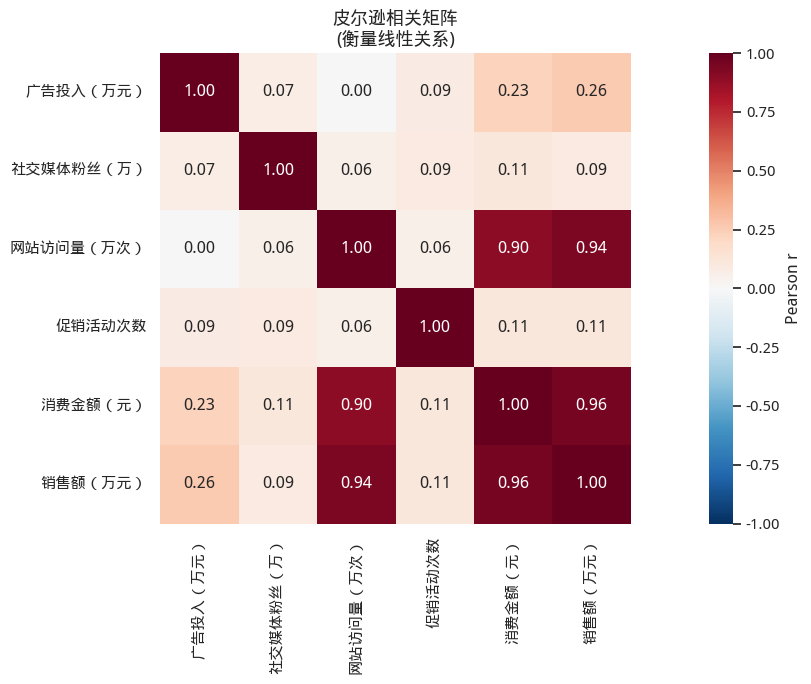

In [34]:
# 用皮尔逊相关矩阵找出所有变量对"销售额"相关性最强的 3 个。
# 选择数值型变量
numeric_cols = ['广告投入（万元）', '社交媒体粉丝（万）', '网站访问量（万次）', 
                '促销活动次数', '消费金额（元）', '销售额（万元）']
df_numeric = df_marketing[numeric_cols]

# 计算皮尔逊相关矩阵
pearson_corr = df_numeric.corr(method='pearson')

print(f"【皮尔逊相关矩阵】")
print(pearson_corr.round(4))

# 提取与销售额的相关性
sales_correlations = pearson_corr['销售额（万元）'].drop('销售额（万元）')

print(f"\n【与销售额的皮尔逊相关系数（按绝对值排序）】")
sorted_corr = sales_correlations.abs().sort_values(ascending=False)
for var in sorted_corr.index:
    corr_val = sales_correlations[var]
    print(f"  {var}: r = {corr_val:.4f}")

# 找出相关性最强的3个变量
top3_pearson = sorted_corr.head(3)
print(f"\n【与销售额相关性最强的3个变量】")
for i, (var, corr) in enumerate(top3_pearson.items(), 1):
    print(f"  {i}. {var}: r = {corr:.4f}")

# 可视化: 相关矩阵热力图对比
fig, ax1 = plt.subplots(1, 1, figsize=(16, 7))

# 皮尔逊相关矩阵热力图
mask = np.zeros_like(pearson_corr, dtype=bool)
# 不使用mask，显示完整矩阵
sns.heatmap(pearson_corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            ax=ax1, vmin=-1, vmax=1, square=True,
            cbar_kws={'label': 'Pearson r'})
ax1.set_title('皮尔逊相关矩阵\n(衡量线性关系)', fontsize=13)
plt.tight_layout()
plt.show()

练习2: 斯皮尔曼相关矩阵对比
【斯皮尔曼相关矩阵】
           广告投入（万元）  社交媒体粉丝（万）  网站访问量（万次）  促销活动次数  消费金额（元）  销售额（万元）
广告投入（万元）     1.0000     0.0777    -0.0074  0.0886   0.2161   0.2435
社交媒体粉丝（万）    0.0777     1.0000     0.0572  0.0962   0.1128   0.0953
网站访问量（万次）   -0.0074     0.0572     1.0000  0.0395   0.9047   0.9441
促销活动次数       0.0886     0.0962     0.0395  1.0000   0.0982   0.1005
消费金额（元）      0.2161     0.1128     0.9047  0.0982   1.0000   0.9597
销售额（万元）      0.2435     0.0953     0.9441  0.1005   0.9597   1.0000

【与销售额的斯皮尔曼相关系数（按绝对值排序）】
  消费金额（元）: ρ = 0.9597
  网站访问量（万次）: ρ = 0.9441
  广告投入（万元）: ρ = 0.2435
  促销活动次数: ρ = 0.1005
  社交媒体粉丝（万）: ρ = 0.0953

【皮尔逊 vs 斯皮尔曼 差异对比】
变量                   皮尔逊 r        斯皮尔曼 ρ       差异 |Δ|       说明
----------------------------------------------------------------------
广告投入（万元）           0.2627       0.2435       0.0192       几乎相同
社交媒体粉丝（万）          0.0922       0.0953       0.0031       几乎相同
网站访问量（万次）          0.9429       0.9441       0.0012       几乎相同
促销活动次数         

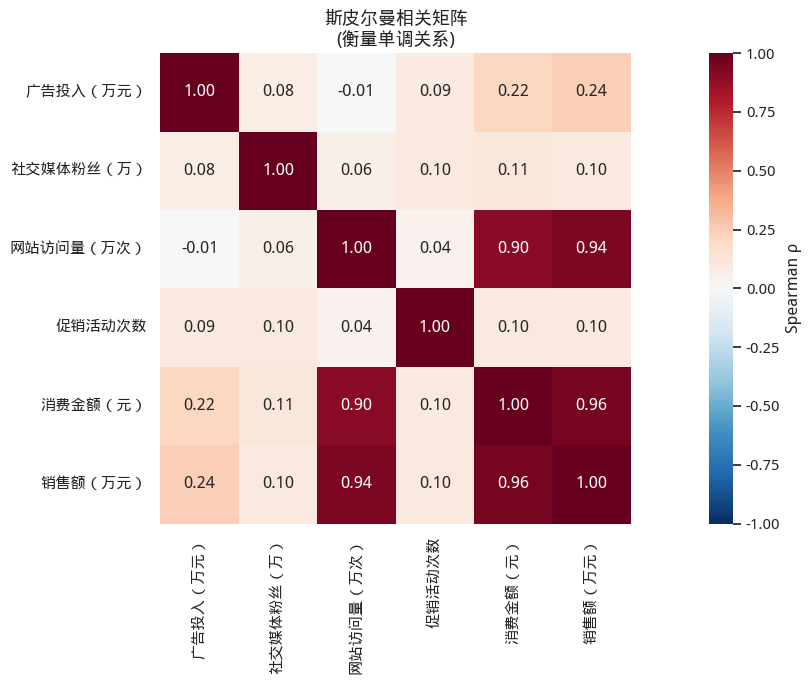

In [36]:
# 练习2: 斯皮尔曼相关矩阵对比
print("练习2: 斯皮尔曼相关矩阵对比")

# 计算斯皮尔曼相关矩阵
spearman_corr = df_numeric.corr(method='spearman')

print(f"【斯皮尔曼相关矩阵】")
print(spearman_corr.round(4))

# 提取与销售额的斯皮尔曼相关性
sales_spearman = spearman_corr['销售额（万元）'].drop('销售额（万元）')

print(f"\n【与销售额的斯皮尔曼相关系数（按绝对值排序）】")
sorted_spearman = sales_spearman.abs().sort_values(ascending=False)
for var in sorted_spearman.index:
    corr_val = sales_spearman[var]
    print(f"  {var}: ρ = {corr_val:.4f}")

# 比较皮尔逊和斯皮尔曼的差异
print(f"\n【皮尔逊 vs 斯皮尔曼 差异对比】")
print(f"{'变量':<20} {'皮尔逊 r':<12} {'斯皮尔曼 ρ':<12} {'差异 |Δ|':<12} {'说明'}")
print("-" * 70)

for var in numeric_cols[:-1]:
    pearson_val = sales_correlations[var]
    spearman_val = sales_spearman[var]
    diff = abs(pearson_val - spearman_val)
    
    # 判断差异程度
    if diff < 0.05:
        note = "几乎相同"
    elif diff < 0.1:
        note = "略有差异"
    elif diff < 0.2:
        note = "明显差异"
    else:
        note = "显著差异"
    
    print(f"{var:<18} {pearson_val:<12.4f} {spearman_val:<12.4f} {diff:<12.4f} {note}")

print(f"\n【差异分析】")
print(f"  皮尔逊相关系数：衡量线性关系的强度和方向")
print(f"  斯皮尔曼相关系数：衡量单调关系的强度和方向，对异常值更稳健")
print(f"\n  如果两者差异较大，说明变量间可能存在非线性单调关系")


# 可视化: 相关矩阵热力图对比
fig, ax2 = plt.subplots(1, 1, figsize=(16, 7))
# 斯皮尔曼相关矩阵热力图
sns.heatmap(spearman_corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            ax=ax2, vmin=-1, vmax=1, square=True,
            cbar_kws={'label': 'Spearman ρ'})
ax2.set_title('斯皮尔曼相关矩阵\n(衡量单调关系)', fontsize=13)

plt.tight_layout()
plt.show()

练习3: 点二列相关系数
【点二列相关系数】
  变量X: 是否使用优惠券 (0/1)
  变量Y: 消费金额（元）

  点二列相关系数 r_pb = 0.3161
  p值 = 0.000005

【分组统计】
  未使用优惠券组 (n=116):
    均值: 247.57 元
    标准差: 83.91 元
  使用优惠券组 (n=84):
    均值: 311.15 元
    标准差: 106.76 元
  均值差异: 63.58 元

  效应量解释: 中等效应
  (|r_pb| < 0.1: 微小, 0.1-0.3: 小, 0.3-0.5: 中等, > 0.5: 大)

  结论 (α = 0.05):
    p值 < 0.05，拒绝原假设
    优惠券使用与消费金额之间存在显著相关


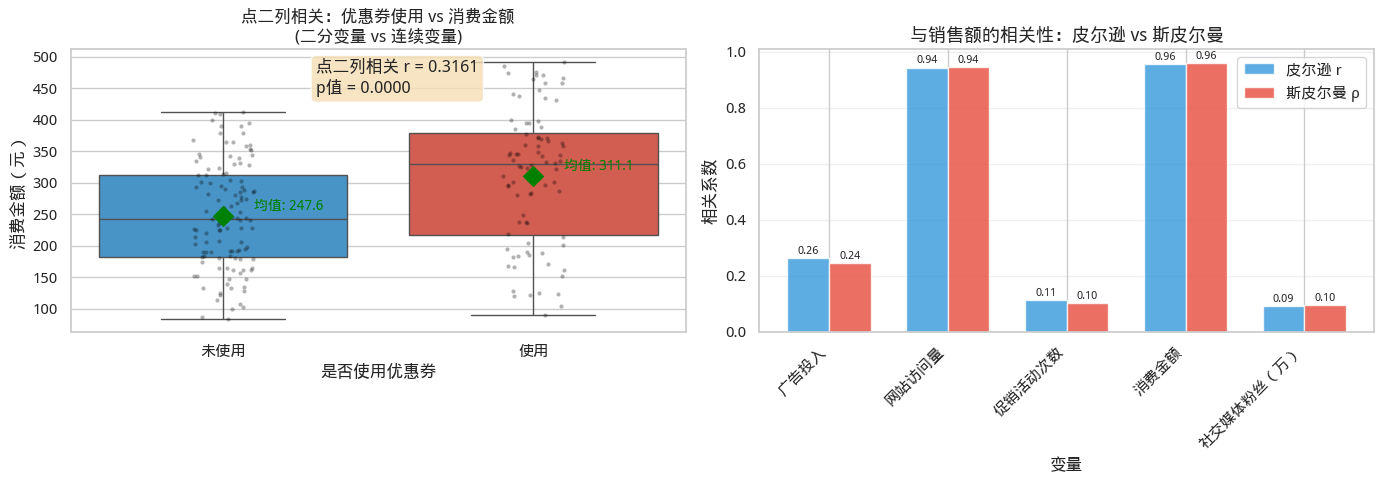

In [50]:
print("练习3: 点二列相关系数")

# 变量：是否使用优惠券（0/1） vs 消费金额
coupon_binary = df_marketing['是否使用优惠券'].values
consumption = df_marketing['消费金额（元）'].values

# 方法1：使用scipy.stats.pointbiserialr
r_pb, p_pb = stats.pointbiserialr(coupon_binary, consumption)

print(f"【点二列相关系数】")
print(f"  变量X: 是否使用优惠券 (0/1)")
print(f"  变量Y: 消费金额（元）")
print(f"\n  点二列相关系数 r_pb = {r_pb:.4f}")
print(f"  p值 = {p_pb:.6f}")

# 补充统计
coupon_0 = consumption[coupon_binary == 0]
coupon_1 = consumption[coupon_binary == 1]

print(f"\n【分组统计】")
print(f"  未使用优惠券组 (n={len(coupon_0)}):")
print(f"    均值: {coupon_0.mean():.2f} 元")
print(f"    标准差: {coupon_0.std():.2f} 元")
print(f"  使用优惠券组 (n={len(coupon_1)}):")
print(f"    均值: {coupon_1.mean():.2f} 元")
print(f"    标准差: {coupon_1.std():.2f} 元")
print(f"  均值差异: {coupon_1.mean() - coupon_0.mean():.2f} 元")

# 效应量解释
abs_r = abs(r_pb)
if abs_r < 0.1:
    effect = "微小"
elif abs_r < 0.3:
    effect = "小"
elif abs_r < 0.5:
    effect = "中等"
else:
    effect = "大"
    
print(f"\n  效应量解释: {effect}效应")
print(f"  (|r_pb| < 0.1: 微小, 0.1-0.3: 小, 0.3-0.5: 中等, > 0.5: 大)")

# 统计显著性
alpha = 0.05
if p_pb < alpha:
    print(f"\n  结论 (α = {alpha}):")
    print(f"    p值 < {alpha}，拒绝原假设")
    print(f"    优惠券使用与消费金额之间存在显著相关")
else:
    print(f"\n  结论 (α = {alpha}):")
    print(f"    p值 >= {alpha}，不能拒绝原假设")
    print(f"    没有足够证据表明优惠券使用与消费金额之间存在显著相关")

# 可视化：点二列相关系数 - 箱线图
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 图1: 箱线图展示优惠券使用与消费金额关系
ax1 = axes[0]
df_marketing['是否使用优惠券'] = df_marketing['是否使用优惠券'].map({0: '未使用', 1: '使用'})
colors = {'未使用': '#3498db', '使用': '#e74c3c'}
sns.boxplot(data=df_marketing, x='是否使用优惠券', hue='是否使用优惠券', y='消费金额（元）', ax=ax1, palette=colors)
sns.stripplot(data=df_marketing, x='是否使用优惠券', y='消费金额（元）', ax=ax1,
              color='black', alpha=0.3, size=3)

# 添加均值标注
means = [coupon_0.mean(), coupon_1.mean()]
for i, mean in enumerate(means):
    ax1.scatter([i], [mean], color='green', s=100, zorder=5, marker='D')
    ax1.annotate(f'均值: {mean:.1f}', xy=(i, mean), xytext=(i+0.1, mean+10),
                fontsize=10, fontweight='bold', color='green')

# 添加点二列相关系数
ax1.annotate(f'点二列相关 r = {r_pb:.4f}\np值 = {p_pb:.4f}', 
             xy=(0.5, df_marketing['消费金额（元）'].max() * 0.9), 
             xytext=(0.3, df_marketing['消费金额（元）'].max() * 0.9),
             fontsize=12, 
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

ax1.set_title('点二列相关：优惠券使用 vs 消费金额\n(二分变量 vs 连续变量)', fontsize=12)
ax1.set_xlabel('是否使用优惠券')
ax1.set_ylabel('消费金额（元）')

# 图2: 相关性排名对比
ax2 = axes[1]
vars_to_compare = ['广告投入（万元）', '网站访问量（万次）', '促销活动次数', 
                   '消费金额（元）', '社交媒体粉丝（万）']
pearson_vals = [sales_correlations[v] for v in vars_to_compare]
spearman_vals = [sales_spearman[v] for v in vars_to_compare]

x = np.arange(len(vars_to_compare))
width = 0.35

bars1 = ax2.bar(x - width/2, pearson_vals, width, label='皮尔逊 r', color='#3498db', alpha=0.8)
bars2 = ax2.bar(x + width/2, spearman_vals, width, label='斯皮尔曼 ρ', color='#e74c3c', alpha=0.8)

ax2.set_xlabel('变量', fontsize=12)
ax2.set_ylabel('相关系数', fontsize=12)
ax2.set_title('与销售额的相关性：皮尔逊 vs 斯皮尔曼', fontsize=13)
ax2.set_xticks(x)
ax2.set_xticklabels([v.replace('（万元）', '').replace('（万次）', '').replace('（元）', '') 
                     for v in vars_to_compare], rotation=45, ha='right')
ax2.legend()
ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax2.grid(axis='y', alpha=0.3)

# 添加数值标签
for bar, val in zip(bars1, pearson_vals):
    ax2.annotate(f'{val:.2f}', xy=(bar.get_x() + bar.get_width()/2, val),
                xytext=(0, 3 if val >= 0 else -10), textcoords="offset points",
                ha='center', fontsize=8)

for bar, val in zip(bars2, spearman_vals):
    ax2.annotate(f'{val:.2f}', xy=(bar.get_x() + bar.get_width()/2, val),
                xytext=(0, 3 if val >= 0 else -10), textcoords="offset points",
                ha='center', fontsize=8)

plt.tight_layout()
plt.show()

本篇完整代码包括练习题解答都已经上传至 GitHub 仓库，欢迎 Clone。

---

## 下期预告

> **第 38 篇：阶段大实战 — A/B 测试完整分析**
>
> 统计学最后一篇大实战：A/B 测试完整分析——假设检验 + 置信区间 + 效应量，走一遍真实项目的完整流程。

---

*跟着小荷，数据分析路上不迷路～*